In [1]:
!pip install -q tensorflow keras opencv-python lxml kagglehub

In [4]:
import kagglehub
path =  kagglehub.dataset_download("jessicali9530/stanford-dogs-dataset")
print(f"Dataset downloaded to:{path}")

Using Colab cache for faster access to the 'stanford-dogs-dataset' dataset.
Dataset downloaded to:/kaggle/input/stanford-dogs-dataset


In [14]:
import os
IMG_DIR = os.path.join(path, "images", "Images")
ANN_DIR = os.path.join(path, "annotations", "Annotation")

assert os.path.exists(IMG_DIR),"Images folder missing"
assert os.path.exists(ANN_DIR),"Annotations folder missing "
print ("Dataset found")

Dataset found


In [10]:
import random
import cv2
import numpy as np
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [15]:
#Label images path
image_paths = []
labels = []

for breed in sorted(os.listdir(IMG_DIR)):
  breed_img = os.path.join(IMG_DIR, breed)
  breed_ann = os.path.join(ANN_DIR, breed)
  if not os.path.isdir(breed_img):continue

  for img_name in os.listdir(breed_img):
    if not img_name.lower().endswith('.jpg'): continue
    img_path = os.path.join(breed_img, img_name)
    xml_path = os.path.join(breed_ann, img_name.replace('.jpg',''))
    if os.path.exists(xml_path):
      try:
        tree = ET.parse(xml_path)
        root = tree.getroot()
        label = root.find('object').find('name').text
        image_paths.append(img_path)
        labels.append(label)
      except:
        continue
print("Total samples :",len(image_paths))

Total samples : 20580


In [16]:
from operator import le
#Encoder lables
le = LabelEncoder()
y = le.fit_transform(labels)
print(le.classes_)

['Afghan_hound' 'African_hunting_dog' 'Airedale'
 'American_Staffordshire_terrier' 'Appenzeller' 'Australian_terrier'
 'Bedlington_terrier' 'Bernese_mountain_dog' 'Blenheim_spaniel'
 'Border_collie' 'Border_terrier' 'Boston_bull' 'Bouvier_des_Flandres'
 'Brabancon_griffon' 'Brittany_spaniel' 'Cardigan'
 'Chesapeake_Bay_retriever' 'Chihuahua' 'Dandie_Dinmont' 'Doberman'
 'English_foxhound' 'English_setter' 'English_springer' 'EntleBucher'
 'Eskimo_dog' 'French_bulldog' 'German_shepherd'
 'German_short-haired_pointer' 'Gordon_setter' 'Great_Dane'
 'Great_Pyrenees' 'Greater_Swiss_Mountain_dog' 'Ibizan_hound'
 'Irish_setter' 'Irish_terrier' 'Irish_water_spaniel' 'Irish_wolfhound'
 'Italian_greyhound' 'Japanese_spaniel' 'Kerry_blue_terrier'
 'Labrador_retriever' 'Lakeland_terrier' 'Leonberg' 'Lhasa' 'Maltese_dog'
 'Mexican_hairless' 'Newfoundland' 'Norfolk_terrier' 'Norwegian_elkhound'
 'Norwich_terrier' 'Old_English_sheepdog' 'Pekinese' 'Pembroke'
 'Pomeranian' 'Rhodesian_ridgeback' 'Rottw

In [17]:
#Train / Val / Test Split
X_train, X_tmp, y_train, y_tmp = train_test_split(
image_paths, y, test_size=0.2, stratify=y, random_state=42)


X_val, X_test, y_val, y_test = train_test_split(
X_tmp, y_tmp, test_size=0.5, stratify=y_tmp, random_state=42)

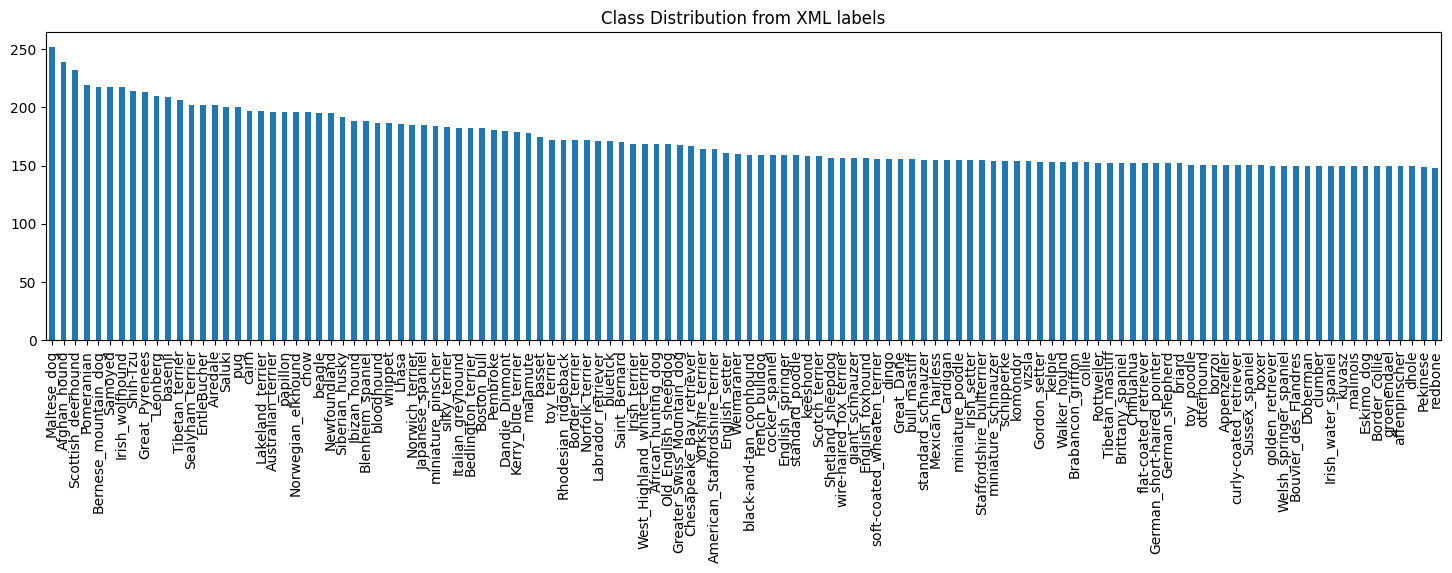

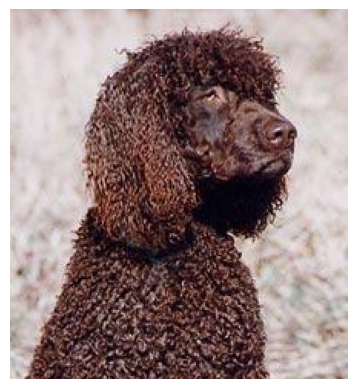

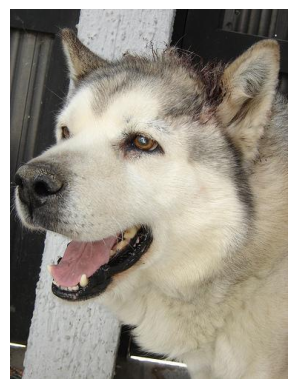

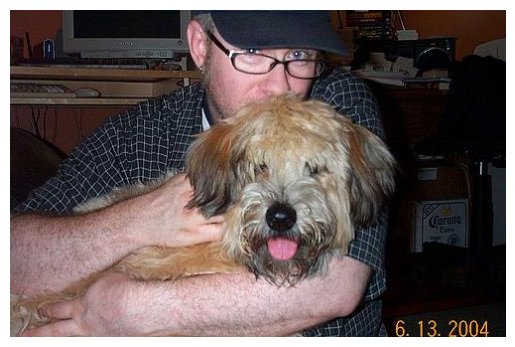

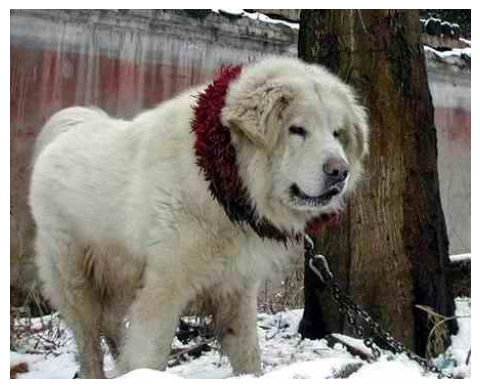

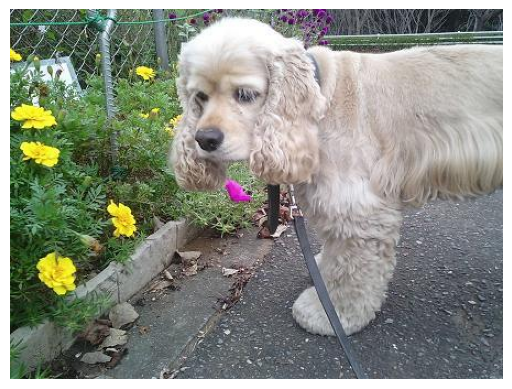

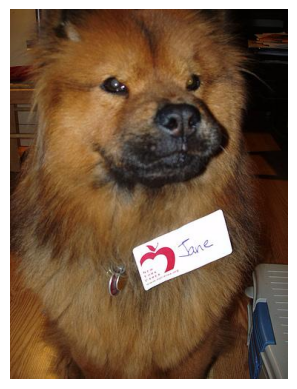

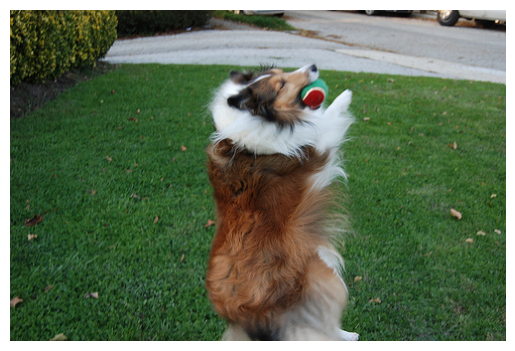

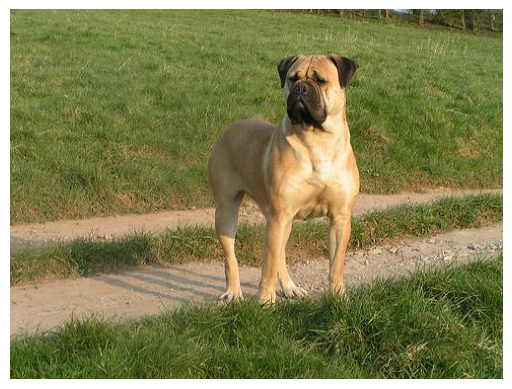

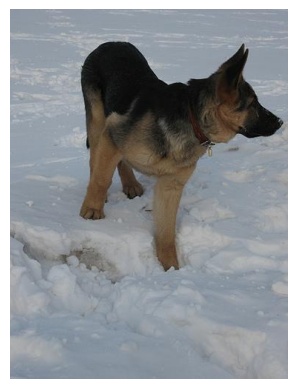

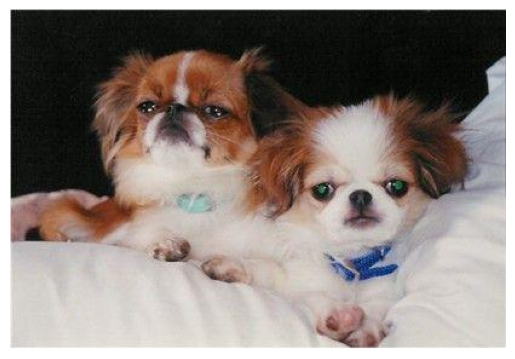

In [18]:
#Data visualization
import pandas as pd
pd.Series(labels).value_counts().plot(kind='bar',figsize=(18,4))
plt.title("Class Distribution from XML labels")
plt.show()

for i in range(10):
  img_path = random.choice(image_paths)
  img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
  plt.imshow(img)
  plt.axis('off')
  plt.show()

In [19]:
#Data Augmentation
IMG_SIZE = 224
BATCH = 32
augment = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2)
])

In [30]:
#Tensorflow pipelining
def preprocess_img(path, label, train=False):
  # Helper function that will be executed in eager mode by tf.py_function
  def _load_and_preprocess_image_eager(image_path_tensor):
    image_path_str = image_path_tensor.numpy().decode('utf-8')
    img = cv2.cvtColor(cv2.imread(image_path_str), cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    # Return as float32 NumPy array, as tf.py_function expects NumPy arrays or TensorFlow Tensors as output
    return img.astype(np.float32)

  # Use tf.py_function to execute the Python-dependent image loading and resizing
  image_tensor = tf.py_function(
      func=_load_and_preprocess_image_eager,
      inp=[path],
      Tout=tf.float32 # Define the output type for the image tensor
  )
  # tf.py_function does not infer the shape, so set it explicitly
  image_tensor.set_shape([IMG_SIZE, IMG_SIZE, 3])

  # Apply augmentation if 'train' is True. 'augment' is a Keras layer and works directly with tf.Tensor.
  if train:
    image_tensor = augment(image_tensor)

  # Return two identical image tensors for the two input branches of the model
  return (image_tensor, image_tensor), label


train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.map(lambda x,y: preprocess_img(x,y,train=True), num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(1000).batch(BATCH).prefetch(tf.data.AUTOTUNE)


val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = val_ds.map(lambda x,y: preprocess_img(x,y), num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)


test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.map(lambda x,y: preprocess_img(x,y), num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH)

In [25]:
# HYBRID MODEL TRANING (ConvNeXt + EfficietnNet)
# Input layers
input1 = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
input2 = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# Get the number of classes from the label encoder
NUM_CLASSES = len(le.classes_)

# Pretrained models
base1 = keras.applications.ConvNeXtSmall(include_top=False, weights='imagenet', input_tensor=input1)
base2 = keras.applications.EfficientNetV2B0(include_top=False, weights='imagenet', input_tensor=input2)


base1.trainable = False
base2.trainable = False


# Global pooling
f1 = layers.GlobalAveragePooling2D()(base1.output)
f2 = layers.GlobalAveragePooling2D()(base2.output)


# Concatenate features
x = layers.Concatenate()([f1, f2])
x = layers.BatchNormalization()(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)


# Model
model = keras.Model([input1, input2], outputs)
model.summary()

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_13      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_small_pre… │ (None, 224, 224,  │          0 │ input_layer_13[0… │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_small_stem │ (None, 56, 56,    │      4,896 │ convnext_small_p… │
│ (Sequential)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_small_sta… │ (None, 56, 56,    │      4,800 │ convnext_small_s… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_small_sta… │ (None, 56, 56,    │        192 │ convnext_small_s… │
│ (LayerNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_small_sta… │ (None, 56, 56,    │     37,248 │ convnext_small_s… │
│ (Dense)             │ 384)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_small_sta… │ (None, 56, 56,    │          0 │ convnext_small_s… │
│ (Activation)        │ 384)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_small_sta… │ (None, 56, 56,    │     36,960 │ convnext_small_s… │
│ (Dense)             │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_small_sta… │ (None, 56, 56,    │         96 │ convnext_small_s… │
│ (LayerScale)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_small_sta… │ (None, 56, 56,    │          0 │ convnext_small_s… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_72 (Add)        │ (None, 56, 56,    │          0 │ convnext_small_s… │
│                     │ 96)               │            │ convnext_small_s… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_small_sta… │ (None, 56, 56,    │      4,800 │ add_72[0][0]      │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_small_sta… │ (None, 56, 56,    │        192 │ convnext_small_s… │
│ (LayerNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_small_sta… │ (None, 56, 56,    │     37,248 │ convnext_small_s… │
│ (Dense)             │ 384)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_small_sta… │ (None, 56, 56,    │          0 │ convnext_small_s… │
│ (Activation)        │ 384)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_small_sta… │ (None, 56, 56,    │     36,960 │ convnext_small_s… │
│ (Dense)             │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_small_sta… │ (None, 56, 56,    │         96 │ convnext_small_s

 Total params: 56,492,840 (215.50 MB)

 Trainable params: 1,114,744 (4.25 MB)

 Non-trainable params: 55,378,096 (211.25 MB)

In [31]:
# COMPILING MODEL AND TRAIN

model.compile(
    optimizer = keras.optimizers.Adam(3e-4),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']

)
model.fit(train_ds, validation_data = val_ds , epochs = 15)

Epoch 1/15
515/515 ━━━━━━━━━━━━━━━━━━━━ 473s 787ms/step - accuracy: 0.5150 - loss: 2.3331 - val_accuracy: 0.9135 - val_loss: 0.3294
Epoch 2/15
515/515 ━━━━━━━━━━━━━━━━━━━━ 350s 658ms/step - accuracy: 0.8281 - loss: 0.6435 - val_accuracy: 0.9174 - val_loss: 0.3195
Epoch 3/15
515/515 ━━━━━━━━━━━━━━━━━━━━ 331s 620ms/step - accuracy: 0.8477 - loss: 0.5368 - val_accuracy: 0.9155 - val_loss: 0.3318
Epoch 4/15
515/515 ━━━━━━━━━━━━━━━━━━━━ 333s 624ms/step - accuracy: 0.8679 - loss: 0.4611 - val_accuracy: 0.9179 - val_loss: 0.3432
Epoch 5/15
515/515 ━━━━━━━━━━━━━━━━━━━━ 333s 623ms/step - accuracy: 0.8833 - loss: 0.3951 - val_accuracy: 0.9174 - val_loss: 0.3629
Epoch 6/15
515/515 ━━━━━━━━━━━━━━━━━━━━ 333s 624ms/step - accuracy: 0.8900 - loss: 0.3672 - val_accuracy: 0.9140 - val_loss: 0.3713
Epoch 7/15
515/515 ━━━━━━━━━━━━━━━━━━━━ 334s 626ms/step - accuracy: 0.8861 - loss: 0.3730 - val_accuracy: 0.9096 - val_loss: 0.4033
Epoch 8/15
515/515 ━━━━━━━━━━━━━━━━━━━━ 335s 627ms/step - accuracy: 0.8962 -

In [35]:
from google.colab import drive
import os

drive.mount('/content/drive')

SAVE_PATH = "/content/drive/MyDrive/model/stanford_dogs_hybrid.keras"

# Create the directory if it doesn't exist
os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)

model.save(SAVE_PATH)
print("Model saved to Google Drive:", SAVE_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model saved to Google Drive: /content/drive/MyDrive/model/stanford_dogs_hybrid.keras


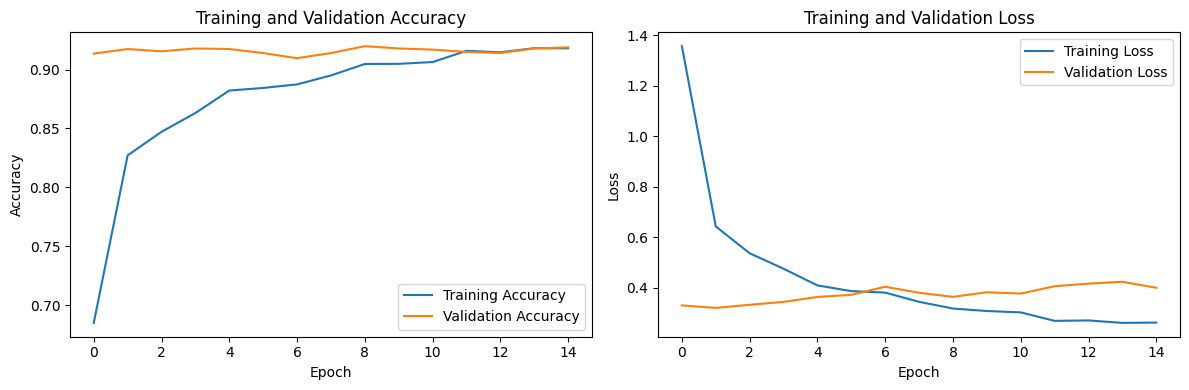

In [37]:
history = model.history

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [36]:
loss, accuracy = model.evaluate(test_ds)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

65/65 ━━━━━━━━━━━━━━━━━━━━ 27s 401ms/step - accuracy: 0.9042 - loss: 0.4007
Test Loss: 0.3705
Test Accuracy: 0.9174
